In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
print("Shape of dataset:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values per column:\n", df.isnull().sum())

Shape of dataset: (150, 5)

Data types:
 sepal length (cm)     float64
sepal width (cm)      float64
petal length (cm)     float64
petal width (cm)      float64
species              category
dtype: object

Missing values per column:
 sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


In [5]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


**Observation:** The dataset has 150 rows and 4 numeric features plus the species
label. There are no missing values, so no cleaning is required — this is a clean,
well-known benchmark dataset.


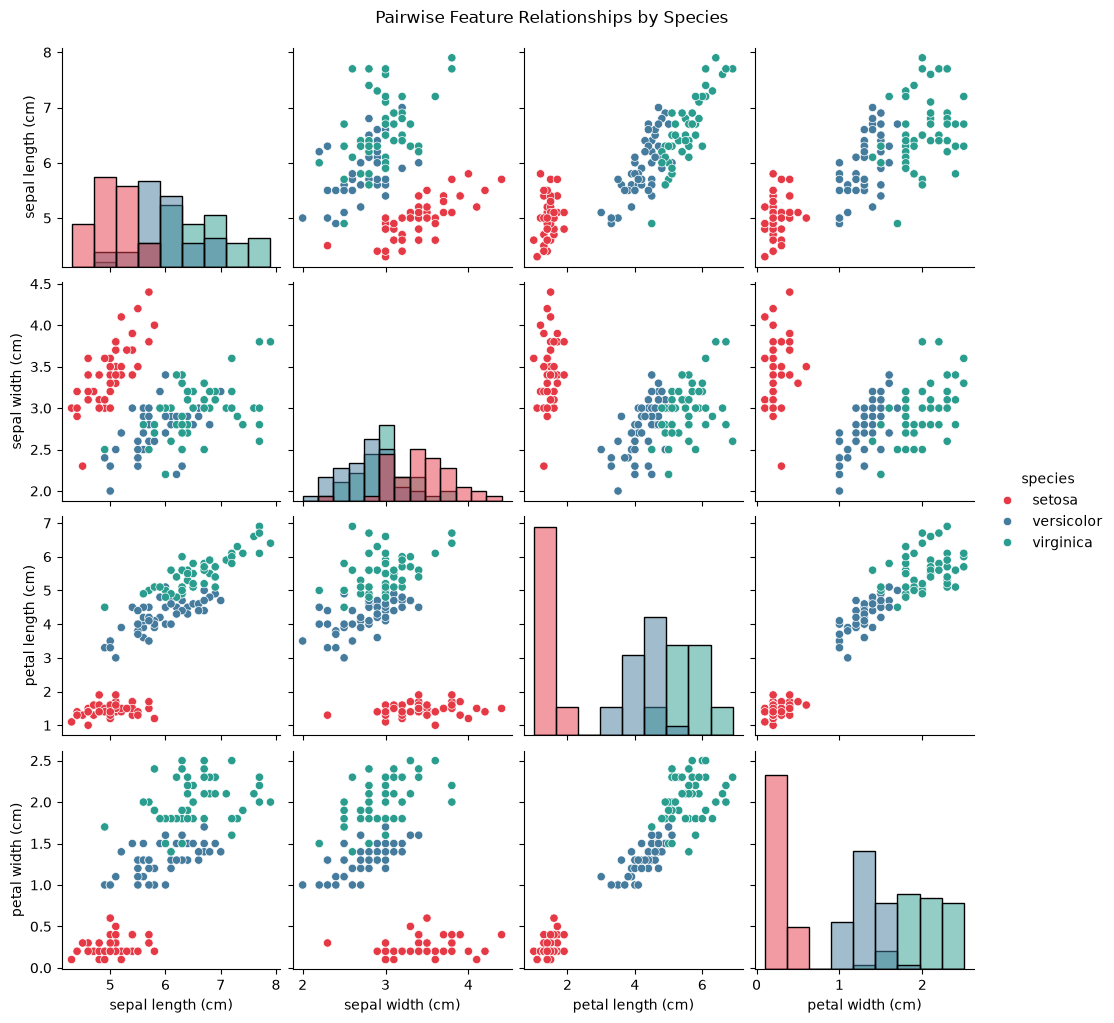

In [8]:
custom_colors = ["#E63946", "#457B9D", "#2A9D8F"]  # red, blue, teal

sns.pairplot(df, hue='species', diag_kind='hist', palette=custom_colors)
plt.suptitle("Pairwise Feature Relationships by Species", y=1.02)
plt.show()

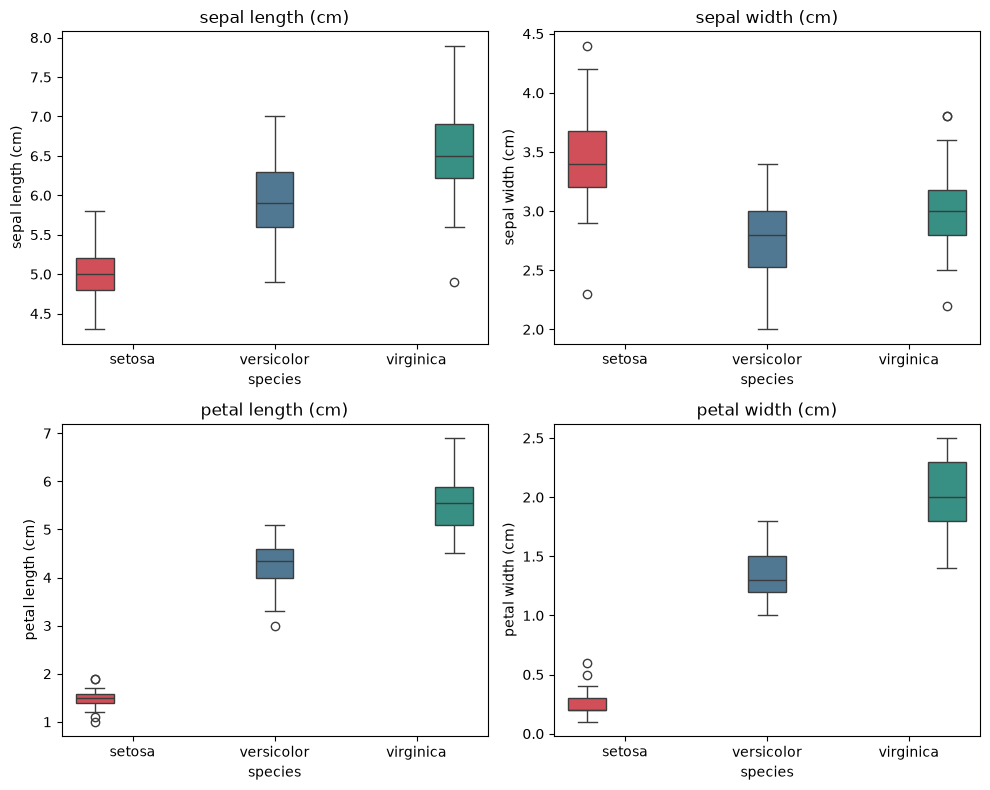

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
features = iris.feature_names
custom_colors = ["#E63946", "#457B9D", "#2A9D8F"]

for ax, feature in zip(axes.flatten(), features):
    sns.boxplot(data=df, x='species', y=feature, hue='species', 
                palette=custom_colors, legend=False, ax=ax)
    ax.set_title(feature)
plt.tight_layout()
plt.show()

**Feature selection discussion:** Looking at the pairplot and box plots, **petal length**
and **petal width** separate the three species far more cleanly than sepal length/width —
especially *Setosa*, which is almost perfectly separated from the other two species on petal
measurements alone. This tells us the petal features are the most discriminative for
classification.

In [12]:
X = df[iris.feature_names]
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


In [13]:
log_reg = LogisticRegression(max_iter=200)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)

print("First 10 predictions:", list(y_pred_lr[:10]))
print("First 10 actual:     ", list(y_test[:10]))

First 10 predictions: ['setosa', 'virginica', 'versicolor', 'versicolor', 'setosa', 'versicolor', 'setosa', 'setosa', 'virginica', 'versicolor']
First 10 actual:      ['setosa', 'virginica', 'versicolor', 'versicolor', 'setosa', 'versicolor', 'setosa', 'setosa', 'virginica', 'versicolor']


In [14]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print("First 10 predictions:", list(y_pred_knn[:10]))
print("First 10 actual:     ", list(y_test[:10]))

First 10 predictions: ['setosa', 'virginica', 'versicolor', 'versicolor', 'setosa', 'versicolor', 'setosa', 'setosa', 'virginica', 'versicolor']
First 10 actual:      ['setosa', 'virginica', 'versicolor', 'versicolor', 'setosa', 'versicolor', 'setosa', 'setosa', 'virginica', 'versicolor']


In [15]:
print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

=== Logistic Regression ===
Accuracy: 0.9666666666666667

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [16]:
print("=== K-Nearest Neighbours ===")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))

=== K-Nearest Neighbours ===
Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



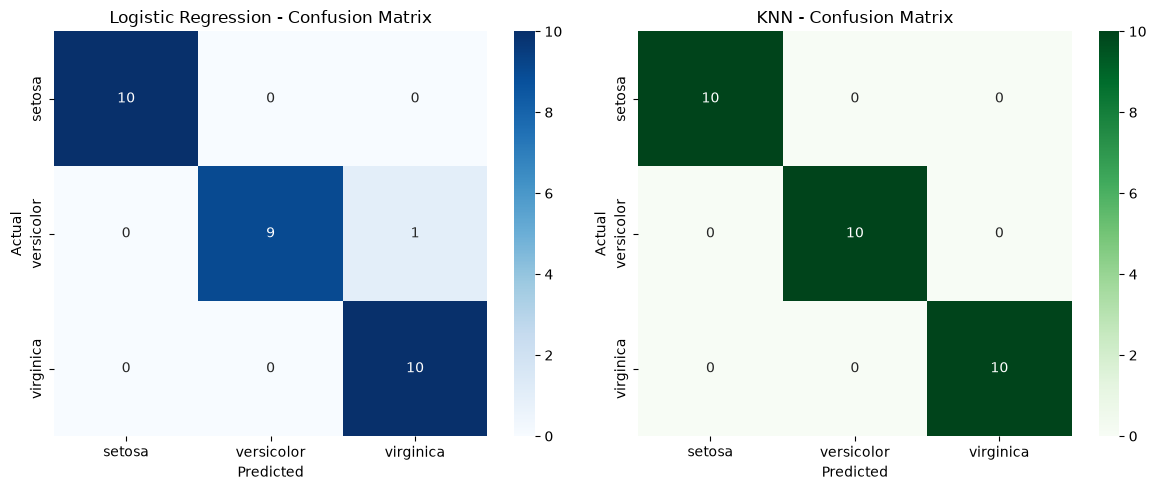

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_lr = confusion_matrix(y_test, y_pred_lr, labels=iris.target_names)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names, yticklabels=iris.target_names, ax=axes[0])
axes[0].set_title("Logistic Regression - Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

cm_knn = confusion_matrix(y_test, y_pred_knn, labels=iris.target_names)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens',
            xticklabels=iris.target_names, yticklabels=iris.target_names, ax=axes[1])
axes[1].set_title("KNN - Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

## Conclusion

Both models performed very well on this dataset, since the Iris classes are close to
linearly separable (especially with petal measurements). Based on the results above:

- **KNN achieved 100% accuracy** (30/30 correct), outperforming Logistic Regression,
  which achieved **96.67% accuracy** (29/30 correct).
- The single Logistic Regression error was a Versicolor flower misclassified as Virginica —
  consistent with the overlap we saw between these two species in the pairplot and box plots.
- **Petal length and petal width** were the most useful features for distinguishing species.
- *Setosa* was perfectly classified by both models — it is fully separable from the other
  two species.

**Best model: K-Nearest Neighbours (KNN)**, based on its perfect accuracy on this test split.